In [2]:
import pandas as pd

entertainment = pd.read_csv("entertainment_seed_channels.csv")
education = pd.read_csv("education_seed_channels.csv")
science = pd.read_csv("science_seed_channels.csv")

df = pd.concat([
    entertainment,
    education,
    science
], ignore_index=True)

df.head()

,creator_name,channel_id,official_channel_title,subscriber_count,video_count,view_count
0,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,MrBeast,497000000,985,127960870175
1,Dude Perfect,UCmo9ZEJ3ipgaZdkiRRYtLAg,Dude Perfect Plus,1440000,32,105411371
2,SSSniperWolf,UCpB959t8iPrxQWj7G6n0ctQ,SSSniperWolf,35000000,4024,26616025538
3,Zach King,UCq8DICunczvLuJJq414110A,Zach King,43000000,851,23121940243
4,Alan Chikin Chow,UC5gxP-2QqIh_09djvlm9Xcg,Alan's Universe,101000000,1704,62111966309


In [3]:
entertainment["category"] = "Entertainment"
education["category"] = "Education"
science["category"] = "Science & Technology"

df = pd.concat([
    entertainment,
    education,
    science
], ignore_index=True)

In [4]:
df["views_per_video"] = df["view_count"] / df["video_count"]

df["subs_per_video"] = df["subscriber_count"] / df["video_count"]

df["views_per_subscriber"] = df["view_count"] / df["subscriber_count"]

df.head()

,creator_name,channel_id,official_channel_title,subscriber_count,video_count,view_count,category,views_per_video,subs_per_video,views_per_subscriber
0,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,MrBeast,497000000,985,127960870175,Entertainment,1.299095e+08,504568.527919,257.466540
1,Dude Perfect,UCmo9ZEJ3ipgaZdkiRRYtLAg,Dude Perfect Plus,1440000,32,105411371,Entertainment,3.294105e+06,45000.000000,73.202341
2,SSSniperWolf,UCpB959t8iPrxQWj7G6n0ctQ,SSSniperWolf,35000000,4024,26616025538,Entertainment,6.614320e+06,8697.813121,760.457873
3,Zach King,UCq8DICunczvLuJJq414110A,Zach King,43000000,851,23121940243,Entertainment,2.717032e+07,50528.789659,537.719541
4,Alan Chikin Chow,UC5gxP-2QqIh_09djvlm9Xcg,Alan's Universe,101000000,1704,62111966309,Entertainment,3.645068e+07,59272.300469,614.969963


In [5]:
df[[
    "subscriber_count",
    "video_count",
    "view_count",
    "views_per_video",
    "subs_per_video"
]].corr()

,subscriber_count,video_count,view_count,views_per_video,subs_per_video
subscriber_count,1.000000,-0.037032,0.930372,0.908775,0.877772
video_count,-0.037032,1.000000,0.035432,-0.159720,-0.183012
view_count,0.930372,0.035432,1.000000,0.842923,0.754244
views_per_video,0.908775,-0.159720,0.842923,1.000000,0.974943
subs_per_video,0.877772,-0.183012,0.754244,0.974943,1.000000


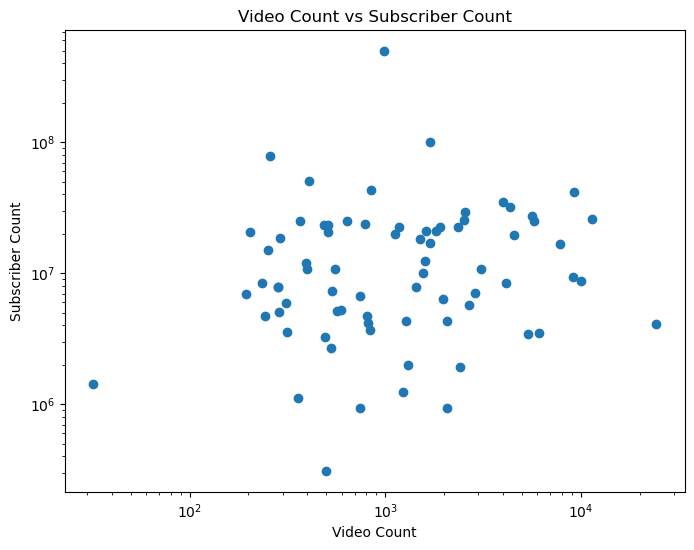

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["video_count"],
    df["subscriber_count"]
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Video Count")
plt.ylabel("Subscriber Count")
plt.title("Video Count vs Subscriber Count")

plt.show()

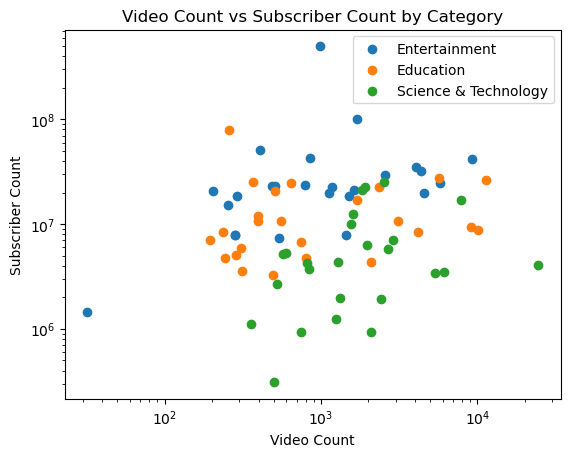

In [7]:
import matplotlib.pyplot as plt

categories = df["category"].unique()

for cat in categories:

    subset = df[df["category"] == cat]

    plt.scatter(
        subset["video_count"],
        subset["subscriber_count"],
        label=cat
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Video Count")
plt.ylabel("Subscriber Count")

plt.legend()

plt.title("Video Count vs Subscriber Count by Category")

plt.show()

In [8]:
import numpy as np
import statsmodels.api as sm

X = np.log(df["video_count"])

y = np.log(df["subscriber_count"])

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       subscriber_count   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.872
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.175
Time:                        11:50:33   Log-Likelihood:                -118.32
No. Observations:                  75   AIC:                             240.6
Df Residuals:                      73   BIC:                             245.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          15.0130      0.811     18.510      

In [9]:
df["subs_per_video"] = (
    df["subscriber_count"] /
    df["video_count"]
)

In [10]:
top_efficiency = (
    df.sort_values(
        "subs_per_video",
        ascending=False
    )
    [["creator_name",
      "category",
      "subscriber_count",
      "video_count",
      "subs_per_video"]]
)

top_efficiency.head(10)

,creator_name,category,subscriber_count,video_count,subs_per_video
0,MrBeast,Entertainment,497000000,985,504568.527919
29,Mark Rober,Education,78200000,258,303100.775194
19,Ben Azelart,Entertainment,50400000,406,124137.931034
12,TheOdd1sOut,Entertainment,20700000,203,101970.443350
28,Kurzgesagt – In a Nutshell,Education,25300000,367,68937.329700
20,Airrack,Entertainment,18600000,290,64137.931034
13,Jaiden Animations,Entertainment,15100000,253,59683.794466
4,Alan Chikin Chow,Entertainment,101000000,1704,59272.300469
3,Zach King,Entertainment,43000000,851,50528.789659
8,Sidemen,Entertainment,23200000,485,47835.051546


In [11]:
category_summary = df.groupby("category").agg({
    "subscriber_count":"mean",
    "video_count":"mean",
    "view_count":"mean",
    "subs_per_video":"mean"
})

category_summary

,subscriber_count,video_count,view_count,subs_per_video
category,,,,
Education,14680000.0,2255.36,2.901102e+09,29011.996200
Entertainment,44524000.0,1800.40,1.719948e+10,52415.771775
Science & Technology,6891240.0,2955.12,2.007510e+09,4150.224564


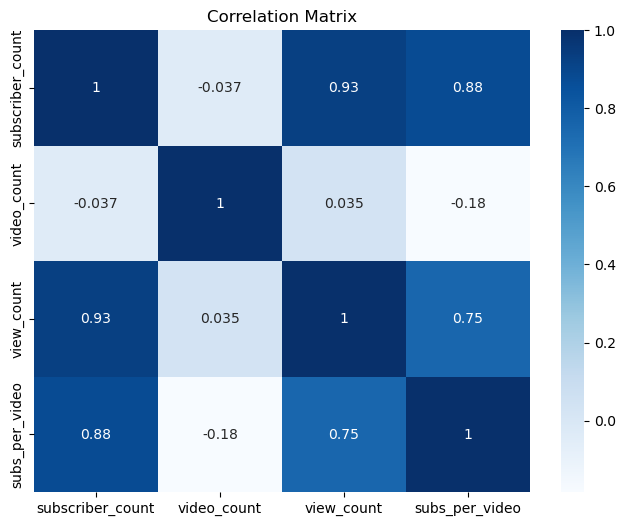

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[[
    "subscriber_count",
    "video_count",
    "view_count",
    "subs_per_video"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

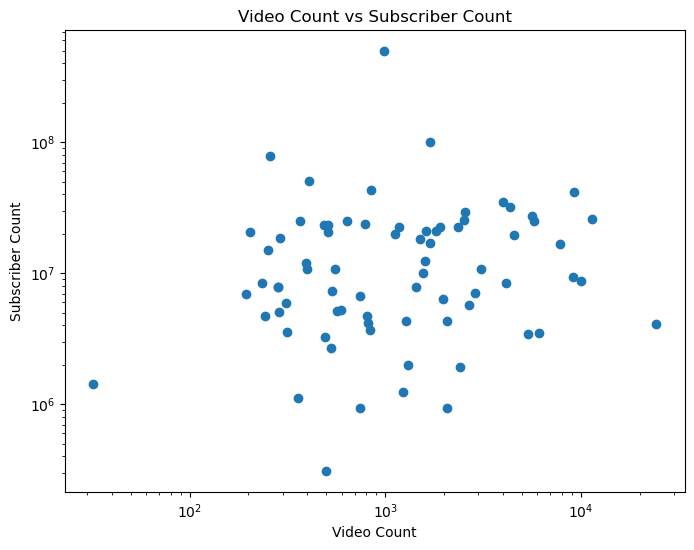

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["video_count"],
    df["subscriber_count"]
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Video Count")
plt.ylabel("Subscriber Count")

plt.title(
    "Video Count vs Subscriber Count"
)

plt.show()

In [14]:
from scipy.stats import kruskal

edu = df[df["category"]=="Education"]["subs_per_video"]

ent = df[df["category"]=="Entertainment"]["subs_per_video"]

sci = df[df["category"]=="Science & Technology"]["subs_per_video"]

kruskal(
    edu,
    ent,
    sci
)

KruskalResult(statistic=np.float64(28.740450931023158), pvalue=np.float64(5.742359481972604e-07))

In [15]:
median_summary = (
    df.groupby("category")
      ["subs_per_video"]
      .median()
)

median_summary

category
Education               11273.885350
Entertainment           27978.723404
Science & Technology     3119.777159
Name: subs_per_video, dtype: float64